In [6]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm

# ------------------------
# Paths
# ------------------------
root = r"D:\D\5th Semester\Machine Learning\Current Signature Dataset of Three-Phase Induction Motor under Varying Load Conditions"
out_csv = r"multi_class_motor_data_stacked_1000features.csv"

rows = []
labels = []
source_file_ids = []
file_counter = 0

def label_from_path_multiclass(path):
    """Naming convention modified to be more descriptive based on original file strings"""
    folder_name = os.path.basename(os.path.dirname(path)).lower()
    file_name = os.path.basename(path).lower()

    # 1. Healthy -> motor_healthy_state
    if "healthy" in folder_name:
        return "motor_healthy_state"

    # 2. Broken rotor bar -> broken_rotor_bar_fault_condition
    if "broken-rotor-bar" in folder_name or "brb" in file_name:
        return "broken_rotor_bar_fault_condition"

    # 3. Bearing faults with severity
    severity = None
    for sev in ["0.7", "0.9", "1.1", "1.3", "1.5", "1.7"]:
        if sev in folder_name:
            severity = sev
            break
    
    if severity is None:
        return "unspecified_motor_fault"

    # 4. Long labels for Inner/Outer with original severity numbers
    if "inner" in file_name:
        return f"bearing_inner_race_fault_v{severity}"
    elif "outer" in file_name:
        return f"bearing_outer_race_fault_v{severity}"
    else:
        return f"general_bearing_fault_v{severity}"

# ------------------------
# Find all CSVs
# ------------------------
csv_files = glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)

# ------------------------
# Process each file
# ------------------------
for f_idx, fpath in enumerate(tqdm(csv_files, desc="Processing data files")):
    file_counter += 1
    try:
        df = pd.read_csv(fpath, header=None)
    except Exception as e:
        print(f"Failed to read {fpath}: {e}")
        continue

    if df.empty or df.shape[1] < 2:
        continue

    # Removing header if present
    df = df.iloc[1:].copy()  

    # Selection of signal columns (skipping timestamp)
    df = df.iloc[:, 1:]

    arr = df.values
    n_rows, n_cols = arr.shape
    
    try:
        label = label_from_path_multiclass(fpath)
    except Exception:
        continue

    # Windowing logic
    for col_idx in range(n_cols):
        col_data = arr[:, col_idx]

        start_idx = 0
        while start_idx < n_rows:
            end_idx = min(start_idx + 1000, n_rows)
            block = col_data[start_idx:end_idx]

            # Padding
            if len(block) < 1000:
                last_val = block[-1] if block.size > 0 else 0
                block = np.pad(block, (0, 1000 - len(block)), mode='constant', constant_values=last_val)

            rows.append(block.tolist())
            labels.append(label)
            source_file_ids.append(file_counter)

            start_idx += 1000

    if (f_idx+1) % 10 == 0 or f_idx == len(csv_files)-1:
        print(f"Processed sequences: {len(rows)}")

# ------------------------
# Saving
# ------------------------
col_names = [f"signal_f{i}" for i in range(1000)] # Added signal_ prefix for columns too
final_df = pd.DataFrame(rows, columns=col_names)
final_df['target_label'] = labels # Changed column name from 'label' to 'target_label'

final_df.to_csv(out_csv, index=False)

print("\n" + "="*50)
print(f"✅ EXPORT COMPLETE: {out_csv}")
print(f"Total entries: {len(final_df)}")
print("-" * 20)
print("Label Distribution:")
print(final_df['target_label'].value_counts())
print("="*50)

Processing data files:   0%|                                                                    | 0/39 [00:00<?, ?it/s]C:\Users\HP\AppData\Local\Temp\ipykernel_2656\1482323204.py:60: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath, header=None)
Processing data files:  15%|█████████▏                                                  | 6/39 [00:01<00:05,  6.00it/s]C:\Users\HP\AppData\Local\Temp\ipykernel_2656\1482323204.py:60: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath, header=None)
Processing data files:  18%|██████████▊                                                 | 7/39 [00:01<00:05,  5.42it/s]C:\Users\HP\AppData\Local\Temp\ipykernel_2656\1482323204.py:60: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath, header=None)
Processing data files:

Processed sequences: 3834


C:\Users\HP\AppData\Local\Temp\ipykernel_2656\1482323204.py:60: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath, header=None)
Processing data files:  31%|██████████████████▏                                        | 12/39 [00:02<00:05,  4.85it/s]C:\Users\HP\AppData\Local\Temp\ipykernel_2656\1482323204.py:60: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath, header=None)
Processing data files:  33%|███████████████████▋                                       | 13/39 [00:02<00:05,  4.78it/s]C:\Users\HP\AppData\Local\Temp\ipykernel_2656\1482323204.py:60: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath, header=None)
Processing data files:  36%|█████████████████████▏                                     | 14/39 [00:02<00:05,  4.86it/s]C:\Users\HP\AppData\Lo

Processed sequences: 8013


Processing data files:  54%|███████████████████████████████▊                           | 21/39 [00:04<00:04,  3.86it/s]C:\Users\HP\AppData\Local\Temp\ipykernel_2656\1482323204.py:60: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath, header=None)
Processing data files:  56%|█████████████████████████████████▎                         | 22/39 [00:04<00:04,  3.93it/s]C:\Users\HP\AppData\Local\Temp\ipykernel_2656\1482323204.py:60: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath, header=None)
Processing data files:  62%|████████████████████████████████████▎                      | 24/39 [00:05<00:03,  4.52it/s]C:\Users\HP\AppData\Local\Temp\ipykernel_2656\1482323204.py:60: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath, header=None)
Processing data files:

Processed sequences: 12018


C:\Users\HP\AppData\Local\Temp\ipykernel_2656\1482323204.py:60: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath, header=None)
Processing data files:  79%|██████████████████████████████████████████████▉            | 31/39 [00:06<00:01,  4.36it/s]C:\Users\HP\AppData\Local\Temp\ipykernel_2656\1482323204.py:60: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath, header=None)
Processing data files:  85%|█████████████████████████████████████████████████▉         | 33/39 [00:07<00:01,  4.51it/s]C:\Users\HP\AppData\Local\Temp\ipykernel_2656\1482323204.py:60: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fpath, header=None)
Processing data files:  90%|████████████████████████████████████████████████████▉      | 35/39 [00:07<00:00,  4.48it/s]C:\Users\HP\AppData\Lo

Processed sequences: 15627



✅ EXPORT COMPLETE: multi_class_motor_data_stacked_1000features.csv
Total entries: 15627
--------------------
Label Distribution:
target_label
bearing_outer_race_fault_v1.1       1284
bearing_inner_race_fault_v0.9       1272
bearing_inner_race_fault_v1.1       1269
bearing_inner_race_fault_v1.5       1236
bearing_inner_race_fault_v1.3       1218
bearing_outer_race_fault_v1.7       1218
bearing_inner_race_fault_v1.7       1218
bearing_outer_race_fault_v0.9       1215
bearing_outer_race_fault_v1.3       1203
bearing_outer_race_fault_v1.5       1182
bearing_inner_race_fault_v0.7       1152
bearing_outer_race_fault_v0.7        987
broken_rotor_bar_fault_condition     822
motor_healthy_state                  351
Name: count, dtype: int64


# Binary 

✅ Binary Data Ready: 10258 Rows, 1000 Features
Training... Iteration 0
Training... Iteration 500
Training... Iteration 1000


C:\Users\HP\AppData\Local\Temp\ipykernel_20152\678505880.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=m_names, y=m_vals, palette='magma')


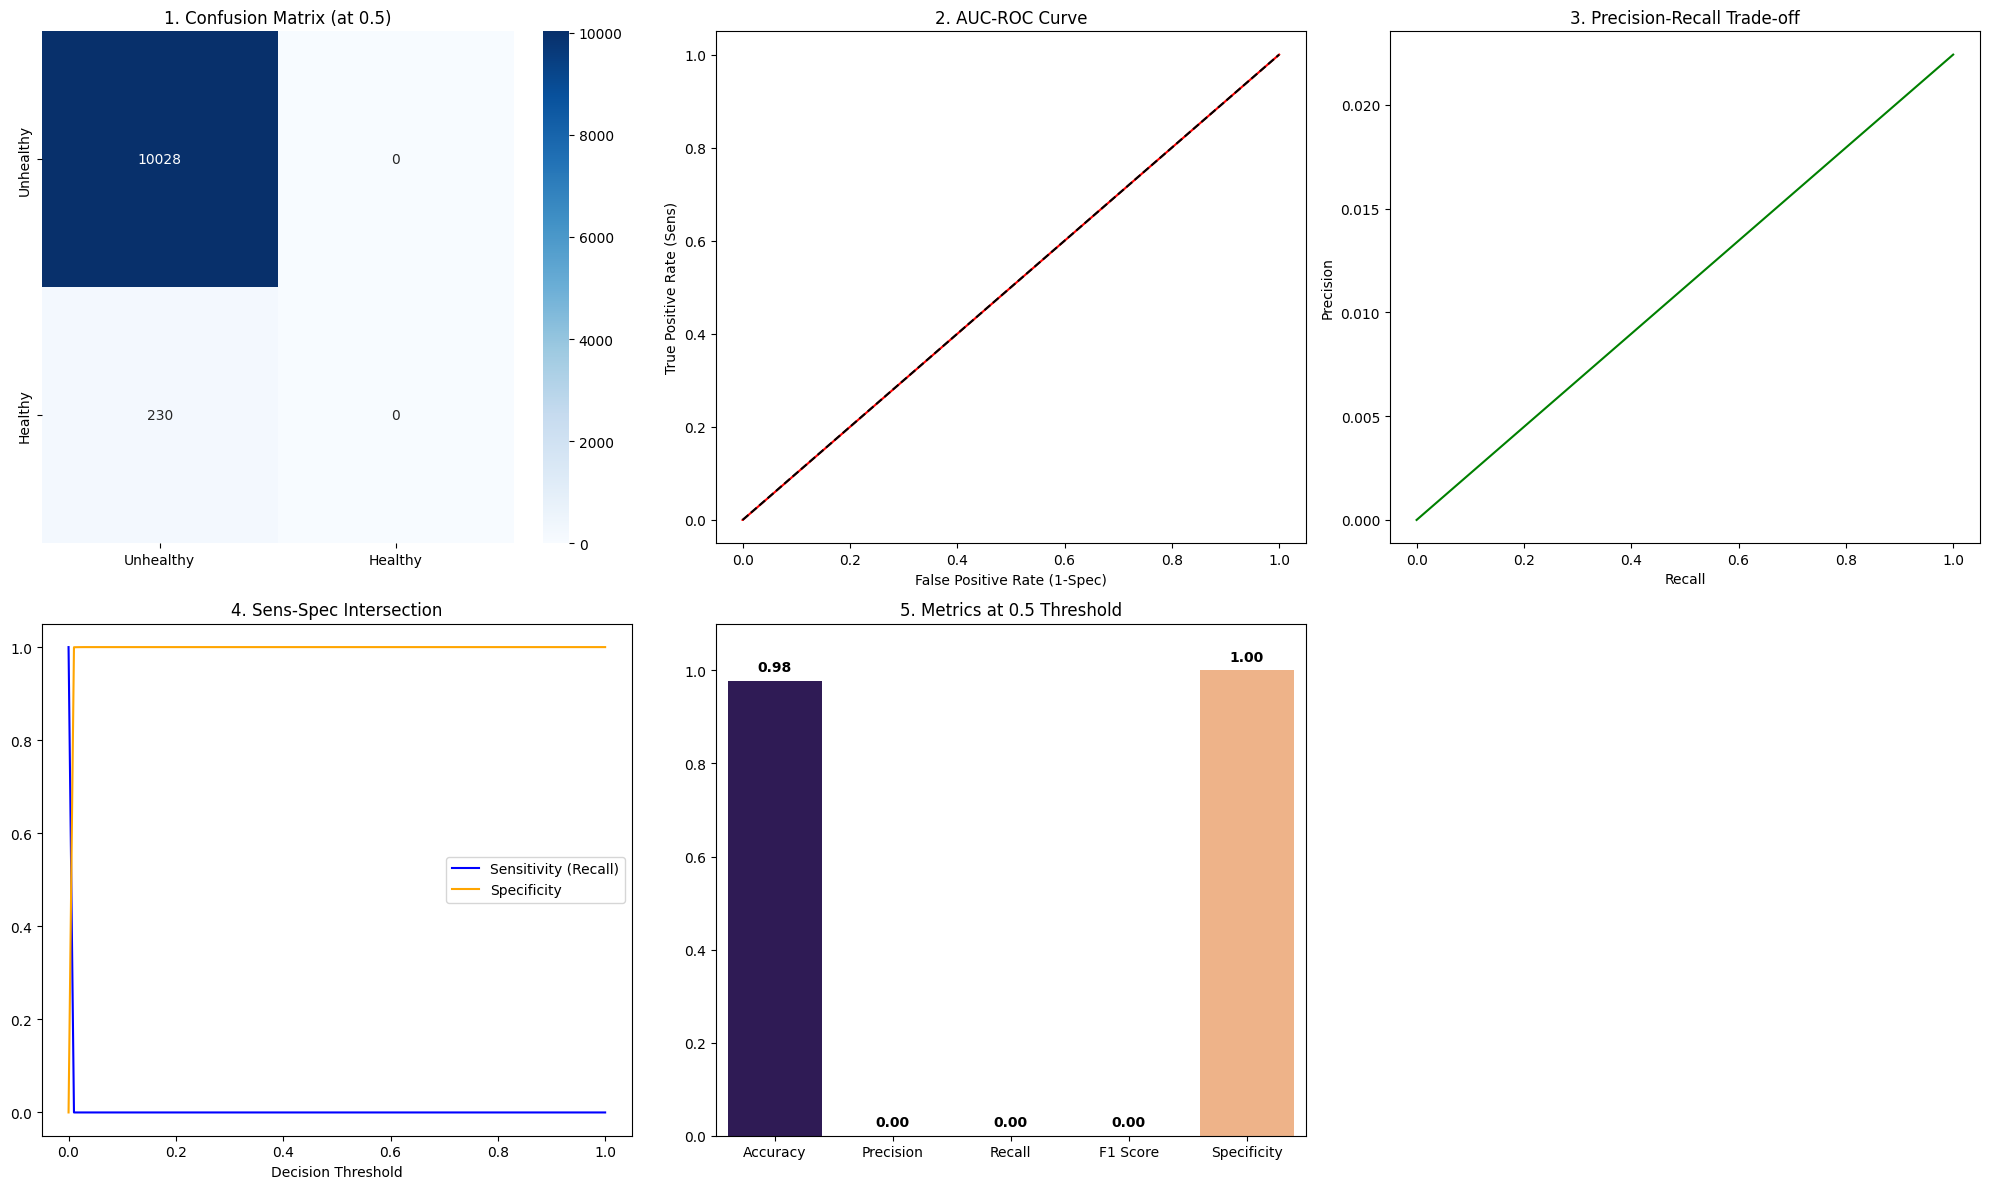


BINARY PERFORMANCE REPORT
Accuracy: 0.9776
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
Specificity: 1.0000


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Data Loading & Cleaning (FIXED) ---
FILE_PATH = 'binary_processed_motor_data_stacked_1000features.csv'

if not os.path.exists(FILE_PATH):
    print(f"❌ Error: '{FILE_PATH}' nahi mili. Path check karein!")
else:
    # low_memory=False aur numeric conversion taake Dtype aur Type errors na ayen
    df = pd.read_csv(FILE_PATH, low_memory=False)
    df = df.apply(pd.to_numeric, errors='coerce').dropna()

    X = df.drop('Label', axis=1).values.astype(float)
    y = df['Label'].values.reshape(-1, 1).astype(float)

    # Manual Standardization
    X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-8)
    print(f"✅ Binary Data Ready: {X.shape[0]} Rows, {X.shape[1]} Features")

# --- 2. Logistic Regression Scratch (FIXED with Clipping) ---
class LogisticRegressionScratch:
    def __init__(self, lr=0.1, iterations=1500):
        self.lr = lr
        self.iterations = iterations

    def sigmoid(self, z):
        # np.clip kernel crash bachane ke liye (Overflow protection)
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        self.w = np.zeros((X.shape[1], 1))
        self.b = 0
        for i in range(self.iterations):
            z = np.dot(X, self.w) + self.b
            y_pred = self.sigmoid(z)
            dw = (1 / len(y)) * np.dot(X.T, (y_pred - y))
            db = (1 / len(y)) * np.sum(y_pred - y)
            self.w -= self.lr * dw
            self.b -= self.lr * db
            if i % 500 == 0:
                print(f"Training... Iteration {i}")

    def predict_prob(self, X):
        return self.sigmoid(np.dot(X, self.w) + self.b)

# Train
model = LogisticRegressionScratch()
model.fit(X, y)
y_probs = model.predict_prob(X)

# --- 3. Threshold Analysis for 9+ Metrics (Exact Logic) ---
thresholds = np.linspace(0, 1, 100)
results = []

for t in thresholds:
    preds = (y_probs >= t).astype(int)
    tp = np.sum((y == 1) & (preds == 1))
    tn = np.sum((y == 0) & (preds == 0))
    fp = np.sum((y == 0) & (preds == 1))
    fn = np.sum((y == 1) & (preds == 0))
    
    acc = (tp + tn) / len(y)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0 # Sensitivity
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    fpr = 1 - spec
    
    results.append([t, acc, prec, rec, spec, f1, fpr])

res_df = pd.DataFrame(results, columns=['Threshold', 'Accuracy', 'Precision', 'Recall', 'Specificity', 'F1', 'FPR'])

# --- 4. VISUALIZATIONS (Wahi 5 Figures jo aapne mangi thin) ---
plt.figure(figsize=(20, 12))

# 1. Confusion Matrix
plt.subplot(2, 3, 1)
final_preds = (y_probs >= 0.5).astype(int)
cm = [[np.sum((y==0)&(final_preds==0)), np.sum((y==0)&(final_preds==1))],
      [np.sum((y==1)&(final_preds==0)), np.sum((y==1)&(final_preds==1))]]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Unhealthy','Healthy'], yticklabels=['Unhealthy','Healthy'])
plt.title("1. Confusion Matrix (at 0.5)")

# 2. AUC-ROC Curve
plt.subplot(2, 3, 2)
plt.plot(res_df['FPR'], res_df['Recall'], color='red', label='ROC Curve')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate (1-Spec)")
plt.ylabel("True Positive Rate (Sens)")
plt.title("2. AUC-ROC Curve")

# 3. Precision-Recall Curve
plt.subplot(2, 3, 3)
plt.plot(res_df['Recall'], res_df['Precision'], color='green')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("3. Precision-Recall Trade-off")

# 4. Sensitivity vs Specificity Trade-off
plt.subplot(2, 3, 4)
plt.plot(thresholds, res_df['Recall'], label='Sensitivity (Recall)', color='blue')
plt.plot(thresholds, res_df['Specificity'], label='Specificity', color='orange')
plt.xlabel("Decision Threshold")
plt.title("4. Sens-Spec Intersection")
plt.legend()

# 5. Bar Chart for 5 Main Metrics (F1, Accuracy, etc.)
plt.subplot(2, 3, 5)
idx = (res_df['Threshold'] - 0.5).abs().idxmin()
m = res_df.iloc[idx]
m_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Specificity']
m_vals = [m['Accuracy'], m['Precision'], m['Recall'], m['F1'], m['Specificity']]
sns.barplot(x=m_names, y=m_vals, palette='magma')
plt.ylim(0, 1.1)
plt.title("5. Metrics at 0.5 Threshold")
for i, v in enumerate(m_vals):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Detailed Print for Report
print("\n" + "="*30)
print("BINARY PERFORMANCE REPORT")
print("="*30)
for i, name in enumerate(m_names):
    print(f"{name}: {m_vals[i]:.4f}")

# Multi 

✅ Multi-Class Ready: 4 Classes, 10258 Samples
Training Class 0...
Training Class 1...
Training Class 2...
Training Class 3...


C:\Users\HP\AppData\Local\Temp\ipykernel_20152\172375647.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=m_names, y=m_vals, palette='viridis')


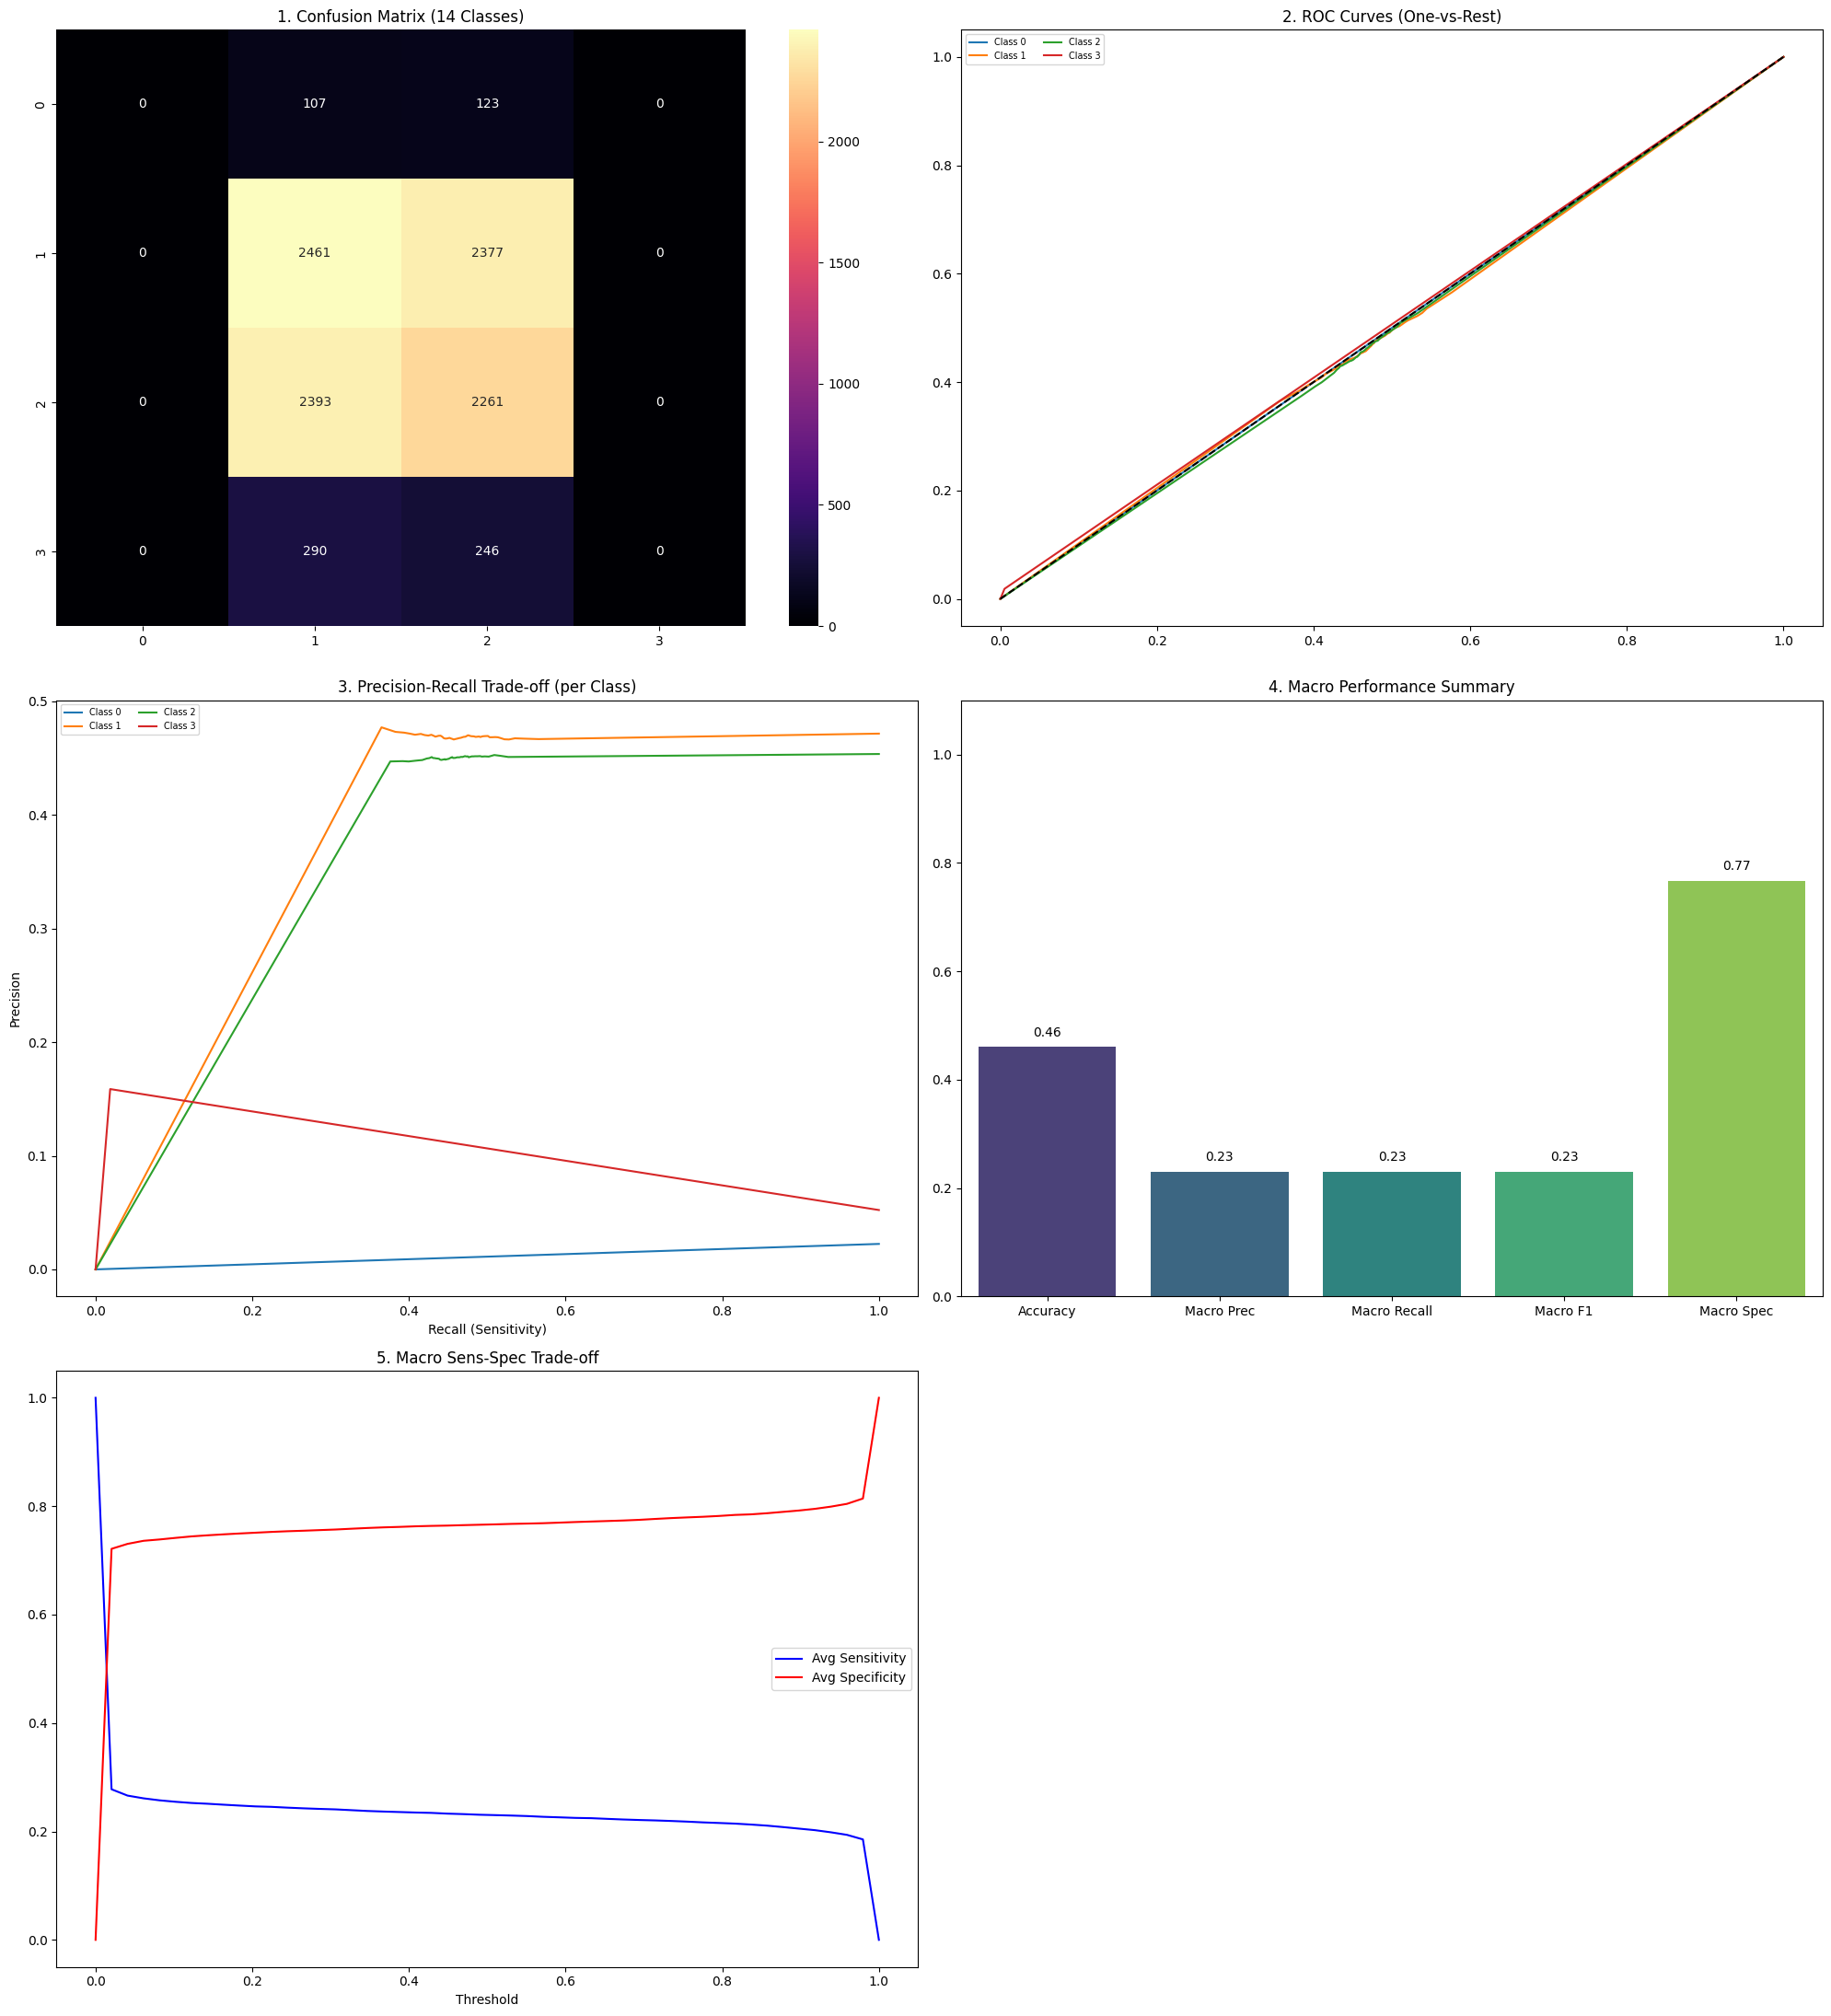

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Data Loading & Cleaning ---
FILE_PATH = 'multi_class_motor_data_stacked_1000features.csv'

if not os.path.exists(FILE_PATH):
    print(f"❌ Error: '{FILE_PATH}' nahi mili.")
else:
    df = pd.read_csv(FILE_PATH, low_memory=False)
    df = df.apply(pd.to_numeric, errors='coerce').dropna()

    X = df.drop('Label', axis=1).values.astype(float)
    y = df['Label'].values.astype(int)

    # Standardization
    X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-8)
    classes = np.unique(y)
    n_classes = len(classes)
    print(f"✅ Multi-Class Ready: {n_classes} Classes, {len(X)} Samples")

# --- 2. Multi-Class Logic (Scratch) ---
class MultiClassLRScratch:
    def __init__(self, lr=0.1, iterations=1000):
        self.lr, self.iterations = lr, iterations
        self.models = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        for c in np.unique(y):
            print(f"Training Class {c}...")
            y_bin = (y == c).astype(float).reshape(-1, 1)
            w = np.zeros((X.shape[1], 1)); b = 0
            for _ in range(self.iterations):
                z = np.dot(X, w) + b
                y_p = self.sigmoid(z)
                w -= self.lr * (1/len(y)) * np.dot(X.T, (y_p - y_bin))
                b -= self.lr * (1/len(y)) * np.sum(y_p - y_bin)
            self.models.append((w, b))

    def predict_probs(self, X):
        return np.column_stack([self.sigmoid(np.dot(X, w) + b) for w, b in self.models])

# Training
model = MultiClassLRScratch()
model.fit(X, y)
probs_mat = model.predict_probs(X)
final_preds = np.argmax(probs_mat, axis=1)

# --- 3. Metrics Calculation for all 14 Classes ---
def get_class_metrics(y_true, probs_mat, target_c):
    y_true_bin = (y_true == target_c).astype(int)
    thresholds = np.linspace(0, 1, 50)
    data = []
    for t in thresholds:
        p_bin = (probs_mat[:, int(target_c)] >= t).astype(int)
        tp = np.sum((y_true_bin==1)&(p_bin==1))
        tn = np.sum((y_true_bin==0)&(p_bin==0))
        fp = np.sum((y_true_bin==0)&(p_bin==1))
        fn = np.sum((y_true_bin==1)&(p_bin==0))
        
        sens = tp/(tp+fn) if (tp+fn)>0 else 0
        spec = tn/(tn+fp) if (tn+fp)>0 else 0
        prec = tp/(tp+fp) if (tp+fp)>0 else 0
        f1 = 2*(prec*sens)/(prec+sens) if (prec+sens)>0 else 0
        data.append([t, sens, spec, prec, f1, 1-spec])
    return pd.DataFrame(data, columns=['T', 'Sens', 'Spec', 'Prec', 'F1', 'FPR'])

# --- 4. VISUALIZATIONS (Ab Precision-Recall Trade-off bhi shamil hai) ---
plt.figure(figsize=(20, 22))

# 1. Confusion Matrix
plt.subplot(3, 2, 1)
cm = np.zeros((n_classes, n_classes))
for a, p in zip(y, final_preds): cm[int(a)][int(p)] += 1
sns.heatmap(cm, annot=True, fmt='.0f', cmap='magma')
plt.title("1. Confusion Matrix (14 Classes)")

# 2. Multi-Class ROC Curves (AUC Visual)
plt.subplot(3, 2, 2)
for c in classes:
    m_df = get_class_metrics(y, probs_mat, c)
    plt.plot(m_df['FPR'], m_df['Sens'], label=f'Class {c}')
plt.plot([0,1],[0,1],'k--')
plt.title("2. ROC Curves (One-vs-Rest)")
plt.legend(ncol=2, fontsize='x-small')

# 3. Precision-Recall Curves (Trade-off Visual)

plt.subplot(3, 2, 3)
for c in classes:
    m_df = get_class_metrics(y, probs_mat, c)
    plt.plot(m_df['Sens'], m_df['Prec'], label=f'Class {c}')
plt.title("3. Precision-Recall Trade-off (per Class)")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.legend(ncol=2, fontsize='x-small')

# 4. Performance Summary Bar Chart
plt.subplot(3, 2, 4)
acc = np.mean(y == final_preds)
all_p, all_r, all_f, all_s = [], [], [], []
for c in classes:
    m_df = get_class_metrics(y, probs_mat, c)
    m = m_df.iloc[25] # 0.5 threshold
    all_p.append(m['Prec']); all_r.append(m['Sens'])
    all_f.append(m['F1']); all_s.append(m['Spec'])

m_names = ['Accuracy', 'Macro Prec', 'Macro Recall', 'Macro F1', 'Macro Spec']
m_vals = [acc, np.mean(all_p), np.mean(all_r), np.mean(all_f), np.mean(all_s)]
sns.barplot(x=m_names, y=m_vals, palette='viridis')
plt.ylim(0, 1.1)
plt.title("4. Macro Performance Summary")
for i, v in enumerate(m_vals): plt.text(i, v+0.02, f"{v:.2f}", ha='center')

# 5. Macro Sens-Spec Trade-off
plt.subplot(3, 2, 5)
mean_sens = np.zeros(50)
mean_spec = np.zeros(50)
for c in classes:
    m_df = get_class_metrics(y, probs_mat, c)
    mean_sens += m_df['Sens'].values
    mean_spec += m_df['Spec'].values
plt.plot(np.linspace(0,1,50), mean_sens/n_classes, label='Avg Sensitivity', color='blue')
plt.plot(np.linspace(0,1,50), mean_spec/n_classes, label='Avg Specificity', color='red')
plt.title("5. Macro Sens-Spec Trade-off")
plt.xlabel("Threshold"); plt.legend()

plt.tight_layout()
plt.show()